# Tech Challenge 2 - Otimizacao Genetica do Diagnostico de Cancer de Mama

Este notebook estende o pipeline de `01_cancer_mama.ipynb` para otimizar os hiperparametros dos tres classificadores da Fase 1 usando um algoritmo genetico implementado no projeto.

**Objetivo clinico:** priorizar a deteccao de tumores malignos (`0 = Maligno`, `1 = Benigno`). Um falso negativo maligno tem custo superior no contexto de apoio ao diagnostico, portanto o `recall` da classe Maligno recebe o maior peso na funcao fitness.

## Desenho experimental e prevencao de vazamento

A divisao treino/teste reproduz a Fase 1: 80/20, estratificada e com `random_state=42`. O algoritmo genetico ve somente os dados de treino e calcula fitness por validacao cruzada estratificada de 5 folds. O teste reservado so e acessado apos a selecao, para comparar os modelos otimizados contra os originais.

A Regressao Logistica e o KNN usam `StandardScaler` dentro de `Pipeline`, de modo que o escalonador e ajustado dentro de cada fold. A Arvore de Decisao nao depende da escala das features.

In [1]:
from pathlib import Path
import json
import os
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
warnings.filterwarnings('ignore', category=DeprecationWarning)

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'src').exists():
    raise FileNotFoundError('Execute o notebook a partir da raiz do repositorio ou de notebooks/.')
sys.path.insert(0, str(ROOT))

from src.genetic_optimization import (
    DEFAULT_EXPERIMENTS,
    GENE_SPACES,
    MODEL_LABELS,
    run_all_experiments,
)

DATA_PATH = ROOT / 'data' / 'cancer_mama.csv'
OUTPUT_DIR = ROOT / 'resultados' / 'fase2'
if not DATA_PATH.exists():
    raise FileNotFoundError('Dataset ausente. Execute: python data/download_datasets.py')

sns.set_theme(style='whitegrid')
print(f'Dataset: {DATA_PATH}')
print(f'Artefatos: {OUTPUT_DIR}')

Dataset: /home/neto/projects/fiap/ai4devs/FASE_1/tech-challenge/data/cancer_mama.csv
Artefatos: /home/neto/projects/fiap/ai4devs/FASE_1/tech-challenge/resultados/fase2


## Codificacao dos genes e operadores

Um individuo e um vetor de indices inteiros. Cada indice seleciona um alelo permitido para um hiperparametro do modelo. Essa representacao categorica evita gerar combinacoes invalidas.

| Operador | Implementacao |
| --- | --- |
| Inicializacao | amostragem aleatoria de um alelo valido por gene |
| Selecao | torneio de 3 individuos |
| Cruzamento | uniforme, escolhendo gene a gene entre dois pais |
| Mutacao | substituicao aleatoria de cada gene conforme a taxa do experimento |
| Elitismo | o melhor individuo passa diretamente para a proxima geracao |

In [2]:
genes_rows = []
for model_key, genes in GENE_SPACES.items():
    for gene, alleles in genes.items():
        genes_rows.append({
            'Modelo': MODEL_LABELS[model_key],
            'Gene': gene,
            'Alelos permitidos': ', '.join(str(value) for value in alleles),
        })
pd.DataFrame(genes_rows)

,Modelo,Gene,Alelos permitidos
0,Regressao Logistica,C,"0.001, 0.01, 0.1, 1.0, 10.0, 100.0"
1,Regressao Logistica,penalty,"l1, l2"
2,Regressao Logistica,class_weight,"None, balanced"
3,KNN,n_neighbors,"1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25"
4,KNN,weights,"uniform, distance"
5,KNN,p,"1, 2"
6,Arvore de Decisao,max_depth,"None, 2, 3, 4, 5, 6, 8, 10"
7,Arvore de Decisao,min_samples_split,"2, 4, 6, 8, 10, 15"
8,Arvore de Decisao,min_samples_leaf,"1, 2, 3, 4, 5"
9,Arvore de Decisao,criterion,"gini, entropy"


## Fitness e configuracoes avaliadas

A fitness combina sensibilidade clinica e desempenho global:

$$fitness = 0.65 \cdot recall_{maligno} + 0.25 \cdot F1_{maligno} + 0.10 \cdot accuracy$$

Foram definidos tres experimentos com diferentes tamanhos de populacao, numero de geracoes e taxas de mutacao/cruzamento. Todos sao aplicados separadamente a Regressao Logistica, KNN e Arvore de Decisao.

In [3]:
configuracoes = pd.DataFrame([
    {
        'Experimento': cfg.name,
        'Populacao': cfg.population_size,
        'Geracoes': cfg.generations,
        'Taxa cruzamento': cfg.crossover_rate,
        'Taxa mutacao': cfg.mutation_rate,
        'Torneio': cfg.tournament_size,
    }
    for cfg in DEFAULT_EXPERIMENTS
])
configuracoes

,Experimento,Populacao,Geracoes,Taxa cruzamento,Taxa mutacao,Torneio
0,E1_pop_pequena_mutacao_baixa,8,6,0.80,0.08,3
1,E2_balanceado,12,8,0.85,0.15,3
2,E3_exploratorio,16,10,0.90,0.30,3


## Execucao dos algoritmos geneticos

A celula abaixo treina os baselines da Fase 1, executa os nove processos de busca (3 configuracoes x 3 modelos), registra o historico por geracao e persiste o pipeline recomendado para inferencia.

In [4]:
resultado = run_all_experiments(DATA_PATH, OUTPUT_DIR, DEFAULT_EXPERIMENTS)
print('Execucao concluida.')
print(f"Modelo disponibilizado pela API: {resultado['artifact_path']}")

2026-06-07T18:54:45 INFO dataset_loaded samples=569 features=30 train=455 test=114
2026-06-07T18:54:46 INFO experiment=E1_pop_pequena_mutacao_baixa model=logistic_regression generation=0 best_fitness=0.95986 mean_fitness=0.92913 recall_maligno=0.95882 candidates=7
2026-06-07T18:54:46 INFO experiment=E1_pop_pequena_mutacao_baixa model=logistic_regression generation=1 best_fitness=0.95986 mean_fitness=0.95008 recall_maligno=0.95882 candidates=10
2026-06-07T18:54:46 INFO experiment=E1_pop_pequena_mutacao_baixa model=logistic_regression generation=2 best_fitness=0.95986 mean_fitness=0.95512 recall_maligno=0.95882 candidates=10
2026-06-07T18:54:46 INFO experiment=E1_pop_pequena_mutacao_baixa model=logistic_regression generation=3 best_fitness=0.95986 mean_fitness=0.95441 recall_maligno=0.95882 candidates=10
2026-06-07T18:54:46 INFO experiment=E1_pop_pequena_mutacao_baixa model=logistic_regression generation=4 best_fitness=0.95986 mean_fitness=0.95858 recall_maligno=0.95882 candidates=10
202

Execucao concluida.
Modelo disponibilizado pela API: /home/neto/projects/fiap/ai4devs/FASE_1/tech-challenge/resultados/fase2/modelo_serving.joblib


## Resultados dos tres experimentos

A tabela apresenta o melhor cromossomo de cada execucao do AG. As colunas prefixadas por `cv_` determinam a selecao do individuo; as demais sao calculadas no conjunto de teste reservado apenas para relatorio.

In [5]:
colunas_experimentos = [
    'modelo', 'experimento', 'cv_fitness', 'cv_recall_maligno',
    'recall_maligno', 'f1_maligno', 'accuracy',
    'falsos_negativos_maligno', 'parametros'
]
experimentos = resultado['experiments'][colunas_experimentos].sort_values(
    ['modelo', 'cv_fitness'], ascending=[True, False]
)
experimentos.style.format({
    'cv_fitness': '{:.4f}', 'cv_recall_maligno': '{:.4f}',
    'recall_maligno': '{:.4f}', 'f1_maligno': '{:.4f}', 'accuracy': '{:.4f}'
}).highlight_max(subset=['cv_fitness'], color='#c6efce')

,modelo,experimento,cv_fitness,cv_recall_maligno,recall_maligno,f1_maligno,accuracy,falsos_negativos_maligno,parametros
5,Arvore de Decisao,E2_balanceado,0.9275,0.9294,0.9048,0.8736,0.9035,4,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": 5, ""min_samples_leaf"": 4, ""min_samples_split"": 6}"
8,Arvore de Decisao,E3_exploratorio,0.9259,0.9294,0.9048,0.9157,0.9386,4,"{""class_weight"": ""balanced"", ""criterion"": ""entropy"", ""max_depth"": 4, ""min_samples_leaf"": 2, ""min_samples_split"": 15}"
2,Arvore de Decisao,E1_pop_pequena_mutacao_baixa,0.9209,0.9235,0.9524,0.8696,0.8947,2,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": 2, ""min_samples_leaf"": 1, ""min_samples_split"": 10}"
1,KNN,E1_pop_pequena_mutacao_baixa,0.9530,0.9471,0.9286,0.9512,0.9649,3,"{""n_neighbors"": 3, ""p"": 1, ""weights"": ""distance""}"
4,KNN,E2_balanceado,0.9530,0.9471,0.9286,0.9512,0.9649,3,"{""n_neighbors"": 3, ""p"": 1, ""weights"": ""uniform""}"
7,KNN,E3_exploratorio,0.9530,0.9471,0.9286,0.9512,0.9649,3,"{""n_neighbors"": 3, ""p"": 1, ""weights"": ""uniform""}"
3,Regressao Logistica,E2_balanceado,0.9753,0.9765,0.9762,0.9425,0.9561,1,"{""C"": 1.0, ""class_weight"": ""balanced"", ""penalty"": ""l2""}"
6,Regressao Logistica,E3_exploratorio,0.9753,0.9765,0.9762,0.9425,0.9561,1,"{""C"": 1.0, ""class_weight"": ""balanced"", ""penalty"": ""l2""}"
0,Regressao Logistica,E1_pop_pequena_mutacao_baixa,0.9686,0.9706,0.9762,0.9535,0.9649,1,"{""C"": 0.1, ""class_weight"": ""balanced"", ""penalty"": ""l2""}"


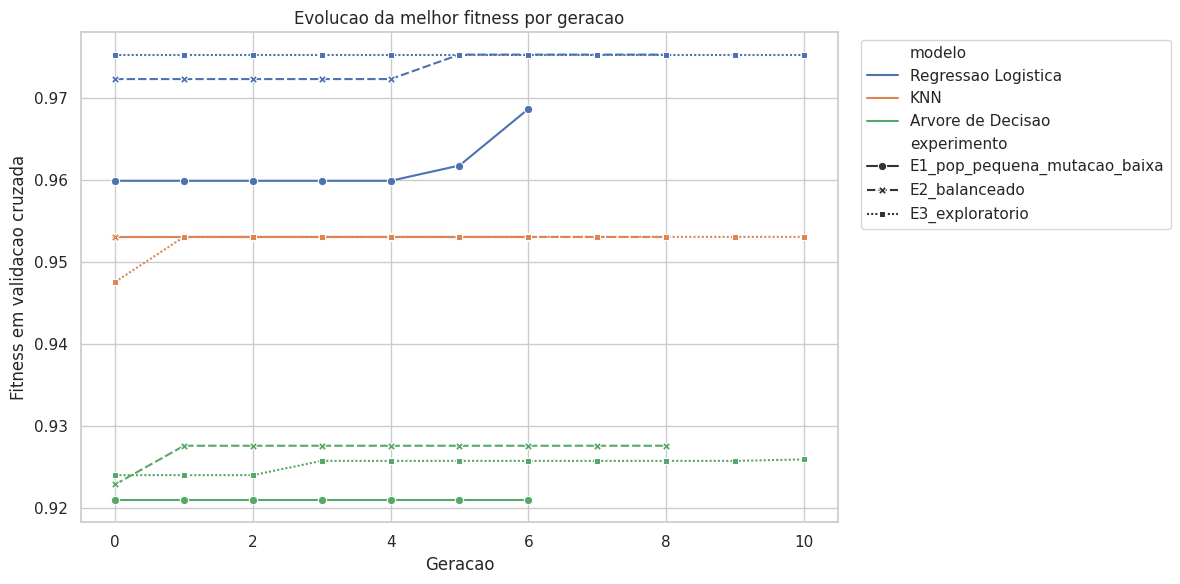

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=resultado['history'], x='generation', y='best_fitness',
    hue='modelo', style='experimento', markers=True, ax=ax
)
ax.set_title('Evolucao da melhor fitness por geracao')
ax.set_xlabel('Geracao')
ax.set_ylabel('Fitness em validacao cruzada')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'evolucao_fitness.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparacao com os modelos originais

Para cada familia de modelo, foi selecionado o experimento com maior fitness em validacao cruzada. A tabela compara esse modelo otimizado com o baseline correspondente da Fase 1 sobre o mesmo conjunto de teste.

In [7]:
comparacao = resultado['comparison'].copy()
colunas_comparacao = [
    'tipo', 'modelo', 'experimento', 'accuracy', 'recall_maligno',
    'f1_maligno', 'falsos_negativos_maligno', 'auc_roc_maligno', 'parametros'
]
comparacao[colunas_comparacao].style.format({
    'accuracy': '{:.4f}', 'recall_maligno': '{:.4f}',
    'f1_maligno': '{:.4f}', 'auc_roc_maligno': '{:.4f}'
}).highlight_max(subset=['recall_maligno', 'f1_maligno', 'auc_roc_maligno'], color='#c6efce').highlight_min(
    subset=['falsos_negativos_maligno'], color='#c6efce'
)

,tipo,modelo,experimento,accuracy,recall_maligno,f1_maligno,falsos_negativos_maligno,auc_roc_maligno,parametros
0,baseline_fase_1,Regressao Logistica,original,0.9825,0.9762,0.9762,1,0.9954,"{""C"": 1.0, ""class_weight"": null, ""penalty"": ""l2"", ""solver"": ""lbfgs""}"
1,baseline_fase_1,KNN,original,0.9737,0.9286,0.9630,3,0.9884,"{""n_neighbors"": 7, ""p"": 2, ""weights"": ""uniform""}"
2,baseline_fase_1,Arvore de Decisao,original,0.9386,0.9286,0.9176,3,0.9342,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": 4, ""min_samples_leaf"": 1, ""min_samples_split"": 2}"
3,otimizado_ag,Regressao Logistica,E2_balanceado,0.9561,0.9762,0.9425,1,0.9954,"{""C"": 1.0, ""class_weight"": ""balanced"", ""penalty"": ""l2""}"
4,otimizado_ag,KNN,E1_pop_pequena_mutacao_baixa,0.9649,0.9286,0.9512,3,0.9716,"{""n_neighbors"": 3, ""p"": 1, ""weights"": ""distance""}"
5,otimizado_ag,Arvore de Decisao,E2_balanceado,0.9035,0.9048,0.8736,4,0.9358,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": 5, ""min_samples_leaf"": 4, ""min_samples_split"": 6}"


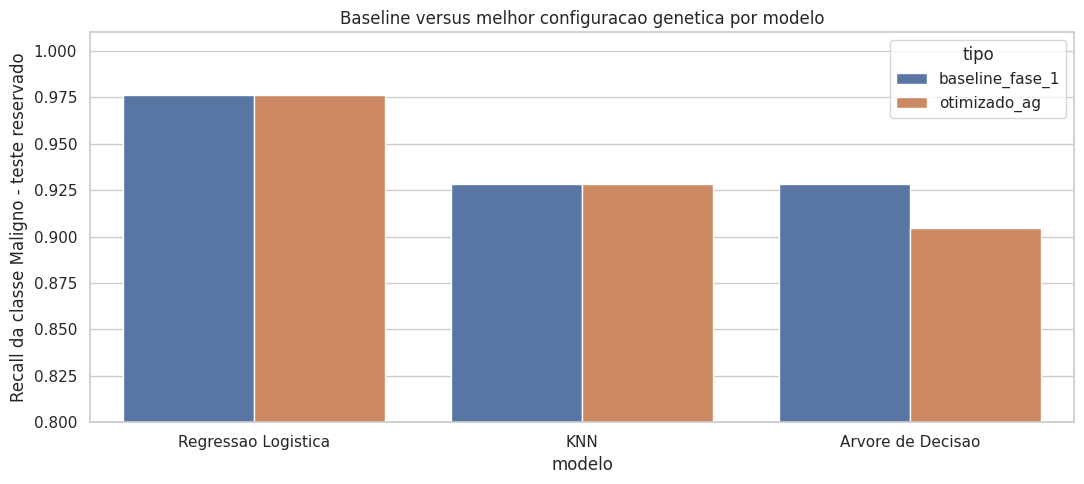

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=comparacao, x='modelo', y='recall_maligno', hue='tipo', ax=ax)
ax.set_ylim(0.80, 1.01)
ax.set_ylabel('Recall da classe Maligno - teste reservado')
ax.set_title('Baseline versus melhor configuracao genetica por modelo')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'comparacao_recall_maligno.png', dpi=150, bbox_inches='tight')
plt.show()

## Melhor modelo otimizado, modelo servido e artefatos

O melhor individuo otimizado e escolhido pela fitness de validacao cruzada. Para a API demonstrativa, a comparacao final determina qual candidato faz sentido servir: como o baseline logistico permanece superior, ele e reajustado com todas as 569 amostras e salvo em `resultados/fase2/modelo_serving.joblib`. Essa escolha de serving usa o teste reservado e nao deve ser interpretada como uma nova estimativa imparcial de producao.

In [9]:
resumo = resultado['summary']
print('Melhor modelo otimizado por validacao cruzada:')
print(json.dumps(resumo['best_optimized'], indent=2, ensure_ascii=False))
print('\nModelo publicado pela API:')
print(json.dumps(resumo['serving_model'], indent=2, ensure_ascii=False))
print('\nArquivos gerados:')
for arquivo in sorted(OUTPUT_DIR.glob('*')):
    print('-', arquivo.name)

Melhor modelo otimizado por validacao cruzada:
{
  "model": "Regressao Logistica",
  "experiment": "E2_balanceado",
  "parameters": {
    "C": 1.0,
    "penalty": "l2",
    "class_weight": "balanced"
  },
  "cv_metrics": {
    "recall_maligno": 0.9764705882352942,
    "f1_maligno": 0.9710070764191465,
    "accuracy": 0.9780219780219781,
    "fitness": 0.9752598492599257
  },
  "test_metrics": {
    "accuracy": 0.956140350877193,
    "precision_weighted": 0.9580981439105009,
    "recall_weighted": 0.956140350877193,
    "f1_weighted": 0.9564299597121931,
    "recall_maligno": 0.9761904761904762,
    "f1_maligno": 0.9425287356321839,
    "falsos_negativos_maligno": 1,
    "auc_roc_maligno": 0.9953703703703705
  }
}

Modelo publicado pela API:
{
  "model": "Regressao Logistica",
  "source": "baseline_fase_1",
  "experiment": "original",
  "parameters": {
    "C": 1.0,
    "class_weight": null,
    "penalty": "l2",
    "solver": "lbfgs"
  },
  "selection_basis": "Melhor resultado observado

## Monitoramento, API e escalabilidade

O treinamento grava `treinamento_ga.log`, `experimentos_ga.csv`, `historico_geracoes.csv` e `resumo_execucao.json`, permitindo rastrear geracoes, parametros, fitness e metricas finais.

O modelo recomendado salvo e consumido por `src/api.py`, que expoe `/predict`, `/health` e `/metrics` (Prometheus). A pasta `deploy/k8s/` configura `Deployment`, `Service` e `HorizontalPodAutoscaler`, escalando replicas da API conforme uso de CPU. A arquitetura e as decisoes de implementacao estao documentadas em `docs/arquitetura_fase2.md`.

## Limitacoes

- O dataset e pequeno e nao representa validacao clinica externa.
- A otimizacao melhora hiperparametros dentro desta amostra; nao comprova generalizacao para outros hospitais ou equipamentos.
- A API e um componente academico de suporte e nao deve ser usada para diagnostico autonomo.